<a href="https://colab.research.google.com/github/crahulnaidu/recursive-self-improving-ai/blob/main/month_1/ai_month_1_day_18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

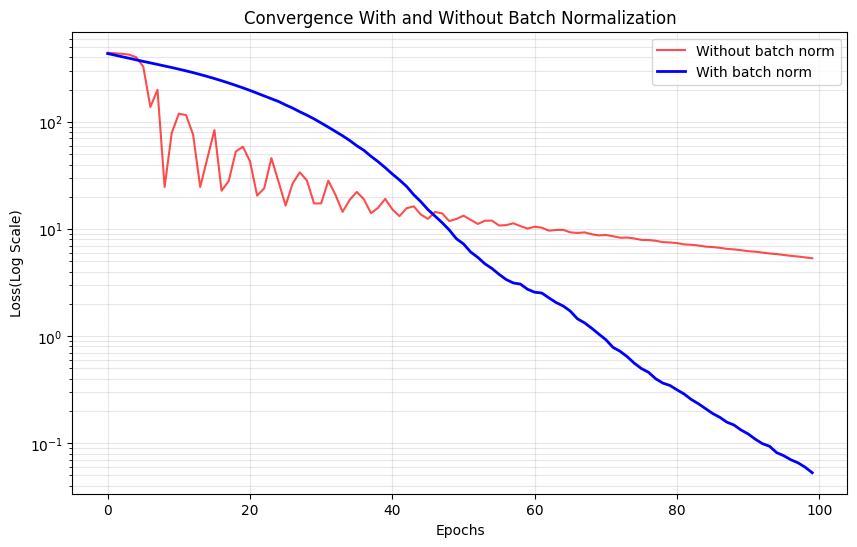

In [3]:
#Set up manual non-linear data for deeper network.

torch.manual_seed(42)
X=torch.randn(1000,20)
Y=torch.sum(X**2,dim=1,keepdim=True)

#Model structure

def create_model(use_bn=False):
  layers=[]
  in_features=20

  #Create a deep network of 10 layers.

  for _ in range(10):
    layers.append(nn.Linear(in_features,50))
    if use_bn:
      layers.append(nn.BatchNorm1d(50))
    layers.append(nn.ReLU())
    in_features=50
  layers.append(nn.Linear(50,1))
  return nn.Sequential(*layers)

#Training function

def train_and_get_loss(model,lr=0.01):
  optimizer=optim.Adam(model.parameters(),lr=lr)
  criterion=nn.MSELoss()
  losses=[]

  for epoch in range(100):
    optimizer.zero_grad()
    output=model(X)
    loss=criterion(output,Y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

  return losses


#Run experiment.

model_no_bn=create_model(use_bn=False)
model_with_bn=create_model(use_bn=True)

loss_no_bn=train_and_get_loss(model_no_bn)
loss_with_bn=train_and_get_loss(model_with_bn)

plt.figure(figsize=(10,6))
plt.plot(loss_no_bn,label="Without batch norm",color='red',alpha=0.7)
plt.plot(loss_with_bn,label="With batch norm",color='blue',linewidth=2)
plt.yscale('log')
plt.title('Convergence With and Without Batch Normalization')
plt.xlabel('Epochs')
plt.ylabel("Loss(Log Scale)")
plt.legend()
plt.grid(True,which="both",ls="-",alpha=0.3)
plt.show()


